# TLCS — Training Notebook

Train the Deep Q-Learning agent for traffic signal control.  
Run cells top-to-bottom in order.

## 1. Environment Setup

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebook directory
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"Project root : {PROJECT_ROOT}")
print(f"src on path  : {SRC}")

Project root : C:\Users\Admin\Desktop\rel301m\refactor
src on path  : C:\Users\Admin\Desktop\rel301m\refactor\src


## 2. GPU Check

In [3]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1024 ** 3
    print(f"GPU available  : {gpu_name}")
    print(f"VRAM           : {vram:.1f} GB")
    print(f"CUDA version   : {torch.version.cuda}")
else:
    device = torch.device("cpu")
    print("No GPU found — training will run on CPU")

print(f"\nPyTorch version  : {torch.__version__}")
print(f"Device in use    : {device}")

GPU available  : NVIDIA GeForce RTX 5060
VRAM           : 8.0 GB
CUDA version   : 12.8

PyTorch version  : 2.12.0.dev20260314+cu128
Device in use    : cuda


## 3. Settings

In [4]:
from constants import DEFAULT_MODEL_PATH, DEFAULT_SETTINGS_PATH, TRAINING_SETTINGS_FILE
from settings import load_training_settings

# Paths are relative to project root
SETTINGS_FILE = PROJECT_ROOT / DEFAULT_SETTINGS_PATH / TRAINING_SETTINGS_FILE
OUT_PATH = PROJECT_ROOT / DEFAULT_MODEL_PATH

settings = load_training_settings(SETTINGS_FILE)
print(f"Settings file : {SETTINGS_FILE}")
print(f"Output path   : {OUT_PATH}")
print()
print(f"Episodes      : {settings.total_episodes}")
print(f"Steps/episode : {settings.max_steps}")
print(f"Cars/episode  : {settings.n_cars_generated}")
print(f"Batch size    : {settings.batch_size}")
print(f"Learning rate : {settings.learning_rate}")
print(f"Gamma         : {settings.gamma}")

Settings file : C:\Users\Admin\Desktop\rel301m\refactor\settings\training_settings.yaml
Output path   : C:\Users\Admin\Desktop\rel301m\refactor\model

Episodes      : 10
Steps/episode : 5400
Cars/episode  : 1000
Batch size    : 100
Learning rate : 0.001
Gamma         : 0.75


## 4. Train

In [5]:
import os

# Run SUMO from the project root so relative paths in the config resolve correctly
os.chdir(PROJECT_ROOT)

from train import training_session

training_session(settings_file=SETTINGS_FILE, out_path=OUT_PATH)

[13:27:36] INFO     Creating new model for the Agent                                                    ]8;id=122143;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py\model.py]8;;\:]8;id=28405;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py#99\99]8;;\

[13:27:37] INFO     Episode 1 of 10                                                                     ]8;id=725815;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=931724;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#79\79]8;;\

[13:27:41] INFO             Epsilon: 1.0                                                               ]8;id=442228;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=368577;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#112\112]8;;\

           INFO             Reward: -40284.0                                                           ]8;id=786093;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=520290;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#113\113]8;;\

           INFO             Cumulative wait: 54374                                                     ]8;id=675260;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=527375;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#114\114]8;;\

...

           INFO             Cumulative wait: 1107880                                                   ]8;id=549373;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=883322;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#114\114]8;;\

           INFO             Avg queue: 205.2                                                           ]8;id=988991;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=150778;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#115\115]8;;\

           INFO     Start time: 2026-03-16 13:27:37.776453                                             ]8;id=548694;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=652166;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#120\120]8;;\

           INFO     End time: 2026-03-16 13:29:26.545115                                               ]8;id=40196;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=996594;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#121\121]8;;\

           INFO     Session info saved at: C:\Users\Admin\Desktop\rel301m\refactor\model               ]8;id=582374;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=370491;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#122\122]8;;\

## 5. Results

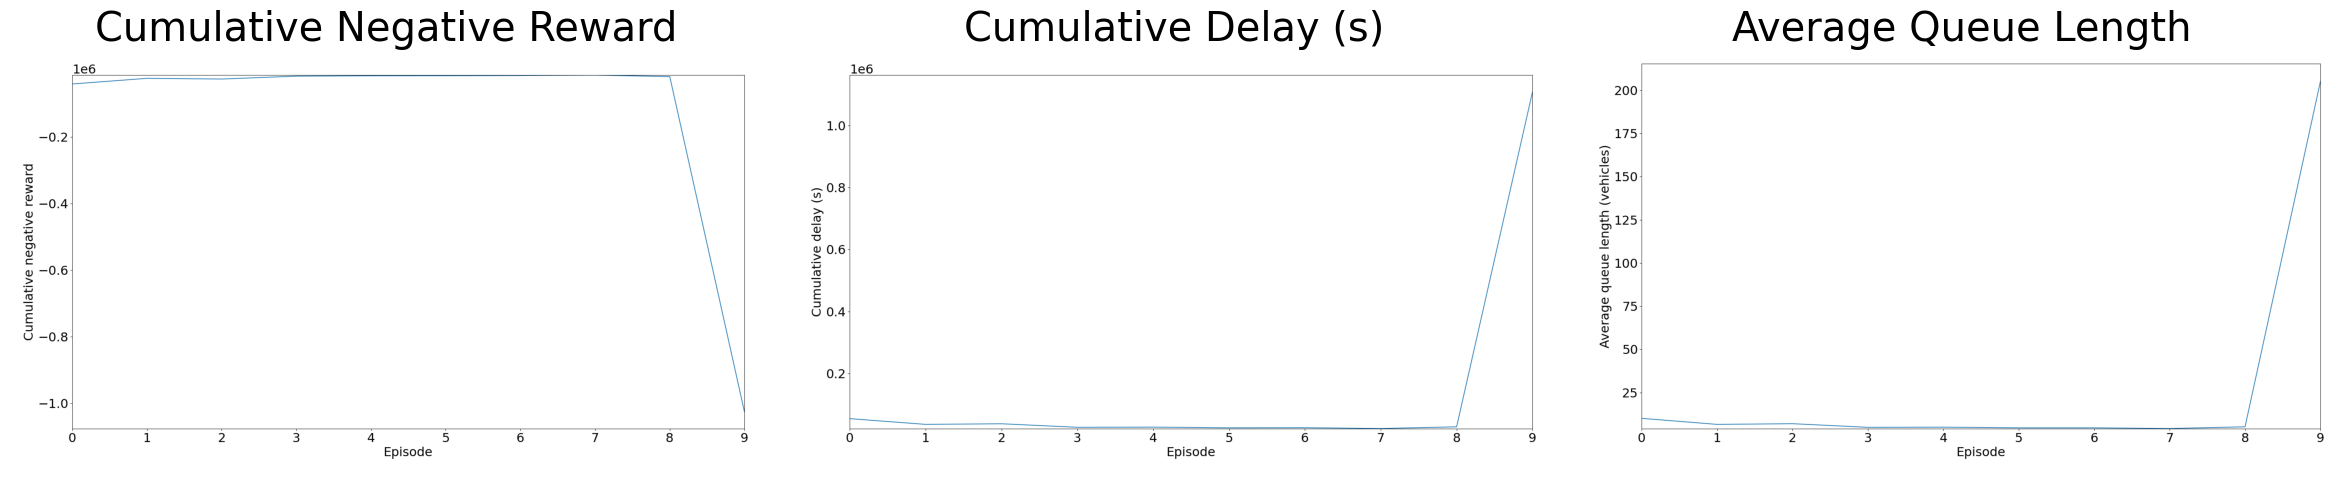

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plots = ["reward", "delay", "queue"]
titles = ["Cumulative Negative Reward", "Cumulative Delay (s)", "Average Queue Length"]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, name, title in zip(axes, plots, titles):
    img_path = OUT_PATH / f"plot_{name}.png"
    if img_path.exists():
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(title)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"{img_path.name}\nnot found", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()